In [107]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3,
})

RESULTS = Path("/Users/fowfloi/Documents/pypsa-earth/results")
OUT = Path("/Users/fowfloi/Documents/pypsa-earth/analysis")
OUT.mkdir(exist_ok=True)

EUR_TO_USD = 1.0 / 0.7532

# Your 6 WACC sweep points (unconstrained)
WACC_POINTS = [0.07, 0.09, 0.11, 0.1379, 0.18, 0.27]
# Your 3 NDC points
NDC_POINTS  = [0.10, 0.1379, 0.27]

BASELINES = {
    "B1_uniform_10":    "cap_exp_2030_uniform_wacc",
    "B2_split_hatton":  "cap_exp_2030_split_wacc",
}

# Gas price sensitivity runs (adjust names to match your actual dirs)
GAS_RUNS = {
    "gas_339": "nigeria_2030_wacc_1379_gas_339",  # update if different
    "gas_600": "nigeria_2030_wacc_1379_gas_600",
}

print(f"EUR_TO_USD = {EUR_TO_USD:.4f}")
print(f"WACC points: {WACC_POINTS}")
print(f"NDC points:  {NDC_POINTS}")

EUR_TO_USD = 1.3277
WACC points: [0.07, 0.09, 0.11, 0.1379, 0.18, 0.27]
NDC points:  [0.1, 0.1379, 0.27]


In [108]:
def load_network(run_name):
    d = RESULTS / run_name / "networks"
    files = list(d.glob("*.nc"))
    return pypsa.Network(files[0]) if files else None

def get_connected(n):
    n.determine_network_topology()
    main_sub = n.buses.sub_network.mode()[0]
    return n.buses.index[n.buses.sub_network == main_sub].tolist()

In [109]:
def summarise(n, wacc, constraint, label):
    EUR_TO_USD_local = 1.0 / 0.7532
    connected = get_connected(n)
    gens = n.generators[n.generators.bus.isin(connected)]
    sto  = n.storage_units[n.storage_units.bus.isin(connected)]

    row = {"run": label, "wacc": wacc, "constraint": constraint}

    cap = gens.groupby("carrier").p_nom_opt.sum() / 1e3
    for c in ["solar", "onwind", "CCGT", "OCGT", "oil", "biomass"]:
        row[f"cap_{c}_gw"] = float(cap.get(c, 0.0))
    bat = sto[sto.carrier == "battery"]
    hyd = sto[sto.carrier == "hydro"]
    row["cap_battery_gw"] = float(bat.p_nom_opt.sum() / 1e3) if len(bat) else 0.0
    row["cap_hydro_gw"]   = float(hyd.p_nom.sum()    / 1e3) if len(hyd) else 0.0

    gen = {}
    for c in gens.carrier.unique():
        cols = gens[gens.carrier == c].index
        if len(cols):
            gen[c] = float(n.generators_t.p[cols].sum().sum() / 1e6)
    if len(hyd):
        gen["hydro"] = float(n.storage_units_t.p[hyd.index].clip(lower=0).sum().sum() / 1e6)
    else:
        gen["hydro"] = 0.0

    for c in ["solar", "onwind", "CCGT", "OCGT", "hydro", "oil", "biomass"]:
        row[f"gen_{c}_twh"] = gen.get(c, 0.0)

    shed = gens[gens.carrier == "load shedding"]
    shed_twh = float(n.generators_t.p[shed.index].sum().sum() / 1e6) if len(shed) else 0.0
    load_cols = [c for c in n.loads_t.p_set.columns if c in connected]
    demand = n.loads_t.p_set[load_cols].sum().sum() / 1e6
    row["demand_twh"] = demand
    row["served_twh"] = demand - shed_twh
    row["shed_twh"]   = shed_twh
    row["shed_pct"]   = 100 * shed_twh / demand if demand else 0.0

    tot = sum(v for k, v in gen.items())
    row["gen_total_twh"] = tot
    if tot > 0:
        row["share_solar_pct"] = 100 * row["gen_solar_twh"] / tot
        row["share_wind_pct"]  = 100 * row["gen_onwind_twh"] / tot
        row["share_renew_pct"] = 100 * (row["gen_solar_twh"] + row["gen_onwind_twh"] + row["gen_hydro_twh"]) / tot
        row["share_gas_pct"]   = 100 * (row["gen_CCGT_twh"] + row["gen_OCGT_twh"]) / tot
    else:
        for k in ["share_solar_pct","share_wind_pct","share_renew_pct","share_gas_pct"]:
            row[k] = 0.0

    # Emissions
    co2_map = n.carriers["co2_emissions"].reindex(gens.carrier.unique()).fillna(0.0)
    eff = gens.efficiency.replace(0, np.nan)
    fuel_mwh = n.generators_t.p[gens.index].div(eff, axis=1)
    emissions_t = fuel_mwh.mul(gens.carrier.map(co2_map), axis=1).sum().sum()
    row["emissions_mt_co2"] = emissions_t / 1e6

    # Costs
    gen_capex = ((gens.p_nom_opt - gens.p_nom).clip(lower=0) * gens.capital_cost).sum()
    gen_opex  = (n.generators_t.p[gens.index] * gens.marginal_cost).sum().sum()
    lines_new = (n.lines.s_nom_opt - n.lines.s_nom).clip(lower=0)
    line_capex = (lines_new * n.lines.capital_cost).sum()
    storage_capex = (sto.capital_cost * sto.p_nom_opt).sum()
    total = gen_capex + gen_opex + line_capex

    row["gen_capex_bn_usd"]     = gen_capex * EUR_TO_USD_local / 1e9
    row["gen_opex_bn_usd"]      = gen_opex  * EUR_TO_USD_local / 1e9
    row["line_capex_bn_usd"]    = line_capex * EUR_TO_USD_local / 1e9
    row["storage_capex_bn_usd"] = storage_capex * EUR_TO_USD_local / 1e9
    row["total_cost_bn_usd"]    = total * EUR_TO_USD_local / 1e9
    row["cost_per_mwh_usd"]     = (total * EUR_TO_USD_local) / (row["served_twh"] * 1e6) if row["served_twh"] else np.nan

    if "s_nom_opt" in n.lines.columns:
        row["line_capacity_gwkm"] = float((n.lines.s_nom_opt * n.lines.length).sum() / 1e3)
    else:
        row["line_capacity_gwkm"] = 0.0

    return row

In [110]:
rows = []

# Unconstrained sweep
for wacc in WACC_POINTS:
    tag = f"{int(round(wacc * 10000)):04d}"
    run_name = f"nigeria_2030_wacc_{tag}"
    n = load_network(run_name)
    if n is None:
        print(f"MISSING: {run_name}")
        continue
    rows.append(summarise(n, wacc, "unconstrained", run_name))
    print(f"Loaded {run_name}")

# NDC sweep
for wacc in NDC_POINTS:
    tag = f"{int(round(wacc * 10000)):04d}"
    run_name = f"nigeria_2030_wacc_{tag}_ndc"
    n = load_network(run_name)
    if n is None:
        print(f"MISSING: {run_name}")
        continue
    rows.append(summarise(n, wacc, "ndc", run_name))
    print(f"Loaded {run_name}")

# Baselines
for label, run_name in BASELINES.items():
    n = load_network(run_name)
    if n is None:
        print(f"MISSING baseline: {label}")
        continue
    rows.append(summarise(n, np.nan, label, run_name))
    print(f"Loaded {label}")

# Gas price sensitivity
for label, run_name in GAS_RUNS.items():
    n = load_network(run_name)
    if n is None:
        print(f"MISSING gas: {label}")
        continue
    rows.append(summarise(n, 0.1379, label, run_name))
    print(f"Loaded {label}")

df = pd.DataFrame(rows)
df.to_csv(OUT / "master_analysis.csv", index=False)
print(f"\nTotal runs loaded: {len(df)}")

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


Loaded nigeria_2030_wacc_0700
Loaded nigeria_2030_wacc_0900


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


Loaded nigeria_2030_wacc_1100


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


...

Loaded nigeria_2030_wacc_1379_ndc
Loaded nigeria_2030_wacc_2700_ndc


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


Loaded B1_uniform_10
Loaded B2_split_hatton
MISSING gas: gas_339


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


Loaded gas_600

Total runs loaded: 12


In [111]:
sweep = df[df.constraint.isin(["unconstrained","ndc"])].copy()
sweep = sweep.sort_values(["constraint","wacc"]).reset_index(drop=True)

t1 = sweep[[
    "wacc","constraint",
    "cap_solar_gw","cap_CCGT_gw","cap_OCGT_gw","cap_battery_gw",
    "gen_solar_twh","gen_hydro_twh","gen_CCGT_twh","gen_OCGT_twh",
    "share_renew_pct","share_gas_pct",
    "emissions_mt_co2","cost_per_mwh_usd"
]].copy()
t1["wacc"] = (t1.wacc * 100).round(2)
t1.to_csv(OUT / "table1_headline.csv", index=False)
t1.round(2)

,wacc,constraint,cap_solar_gw,cap_CCGT_gw,cap_OCGT_gw,cap_battery_gw,gen_solar_twh,gen_hydro_twh,gen_CCGT_twh,gen_OCGT_twh,share_renew_pct,share_gas_pct,emissions_mt_co2,cost_per_mwh_usd
0,10.00,ndc,26.02,3.44,9.31,9.32,44.35,8.41,8.57,12.21,71.74,28.26,8.82,28.37
1,13.79,ndc,26.28,3.44,10.14,8.76,44.42,8.37,8.21,12.47,71.86,28.14,8.82,37.33
2,27.00,ndc,26.02,6.38,8.74,7.19,42.82,8.27,13.31,8.86,69.73,30.27,8.82,70.74
3,7.00,unconstrained,4.61,3.44,27.11,0.41,7.99,8.45,9.26,46.37,22.81,77.19,25.55,35.52
4,9.00,unconstrained,3.60,3.44,27.95,0.08,6.25,8.45,9.26,48.06,20.41,79.58,26.37,36.77
5,11.00,unconstrained,3.25,3.44,28.25,0.00,5.64,8.45,9.26,48.67,19.57,80.43,26.66,37.46
6,13.79,unconstrained,2.81,3.44,28.56,0.00,4.88,8.45,9.26,49.43,18.51,81.49,27.03,38.14
7,18.00,unconstrained,2.13,3.44,29.15,0.00,3.71,8.45,9.26,50.60,16.88,83.12,27.60,38.99
8,27.00,unconstrained,0.00,3.44,31.59,0.00,0.00,8.45,9.26,54.31,11.73,88.26,29.39,39.62


In [113]:
def find_wacc(sub, cond):
    sub = sub.sort_values("wacc")
    hit = sub[cond]
    return float(hit.wacc.iloc[0] * 100) if len(hit) else None

inf_rows = []
for constraint in ["unconstrained","ndc"]:
    sub = sweep[sweep.constraint == constraint].reset_index(drop=True)
    inf_rows.append({
        "constraint": constraint,
        "solar_cap > gas_cap":  find_wacc(sub, sub.cap_solar_gw >= sub.cap_CCGT_gw + sub.cap_OCGT_gw),
        "solar_gen > gas_gen":  find_wacc(sub, sub.gen_solar_twh >= sub.gen_CCGT_twh + sub.gen_OCGT_twh),
        "renew_share > 30%":    find_wacc(sub, sub.share_renew_pct >= 30),
        "renew_share > 50%":    find_wacc(sub, sub.share_renew_pct >= 50),
        "renew_share > 70%":    find_wacc(sub, sub.share_renew_pct >= 70),
    })

inf = pd.DataFrame(inf_rows)
inf.to_csv(OUT / "table2_inflection.csv", index=False)
inf.round(2)

,constraint,solar_cap > gas_cap,solar_gen > gas_gen,renew_share > 30%,renew_share > 50%,renew_share > 70%
0,unconstrained,NaN,NaN,NaN,NaN,NaN
1,ndc,10.0,10.0,10.0,10.0,10.0


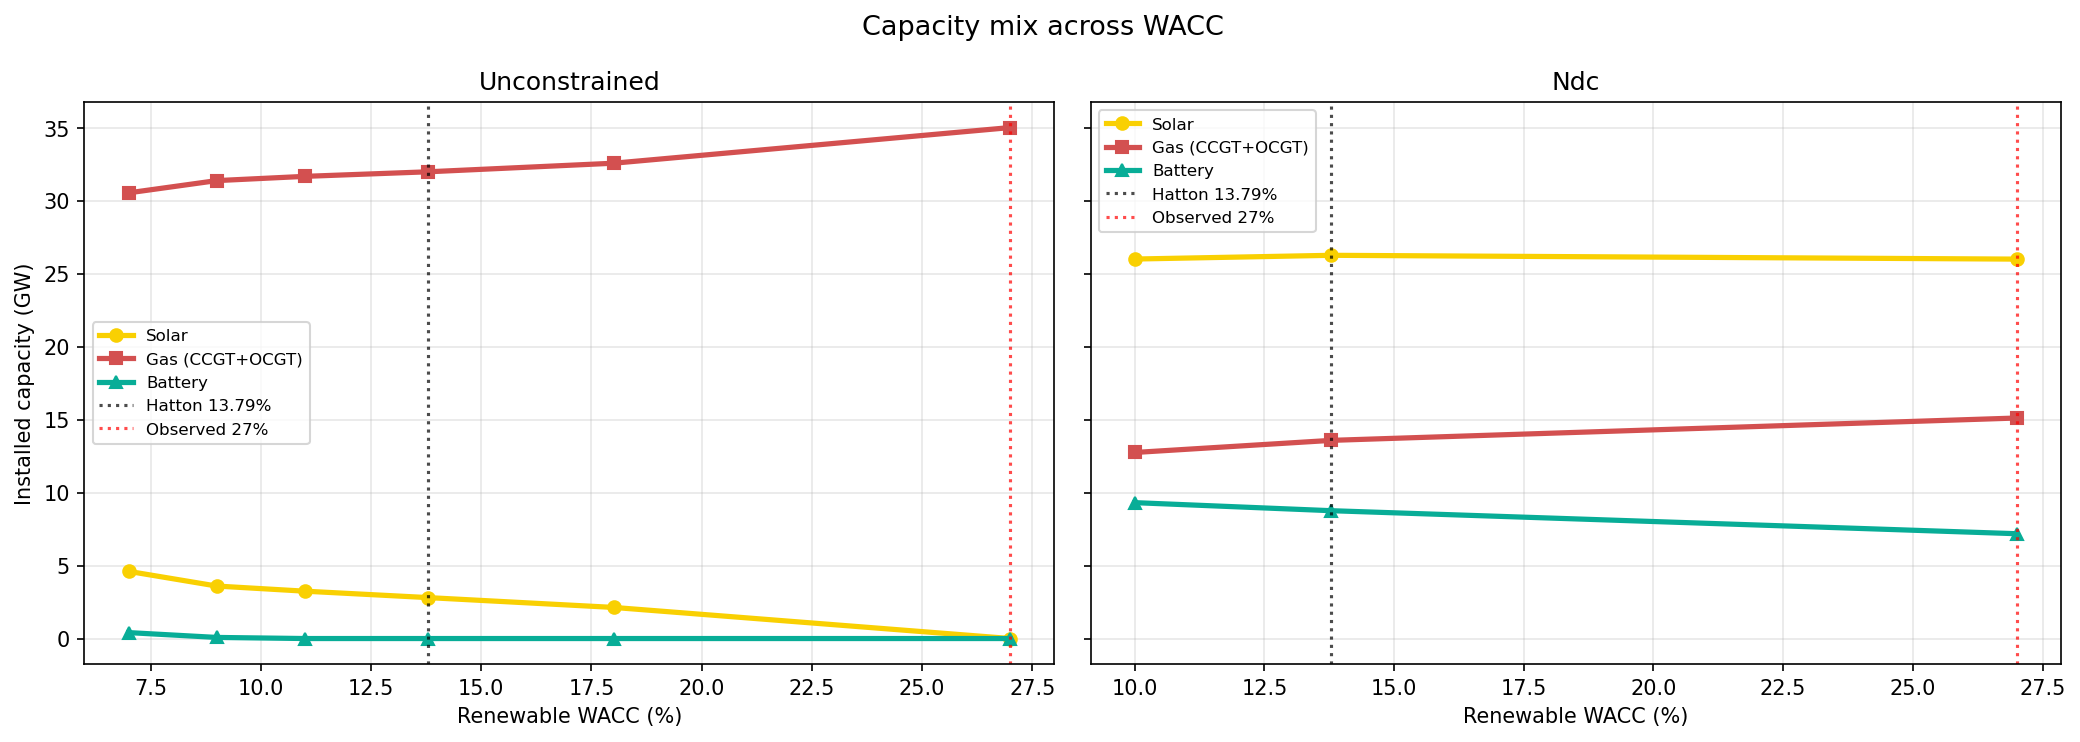

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, c in zip(axes, ["unconstrained","ndc"]):
    sub = sweep[sweep.constraint == c].sort_values("wacc")
    x = sub.wacc * 100
    ax.plot(x, sub.cap_solar_gw, "o-", color="#f9d002", lw=2.5, label="Solar")
    ax.plot(x, sub.cap_CCGT_gw + sub.cap_OCGT_gw, "s-", color="#d35050", lw=2.5, label="Gas (CCGT+OCGT)")
    ax.plot(x, sub.cap_battery_gw, "^-", color="#08ad97", lw=2.5, label="Battery")
    ax.axvline(13.79, color="black", ls=":", alpha=0.7, label="Hatton 13.79%")
    ax.axvline(27, color="red", ls=":", alpha=0.7, label="Observed 27%")
    ax.set_xlabel("Renewable WACC (%)")
    ax.set_title(c.capitalize())
    ax.legend(fontsize=8)
axes[0].set_ylabel("Installed capacity (GW)")
fig.suptitle("Capacity mix across WACC", fontsize=13)
plt.tight_layout()
plt.savefig(OUT / "fig1_capacity_crossover.png", bbox_inches="tight")
plt.show()

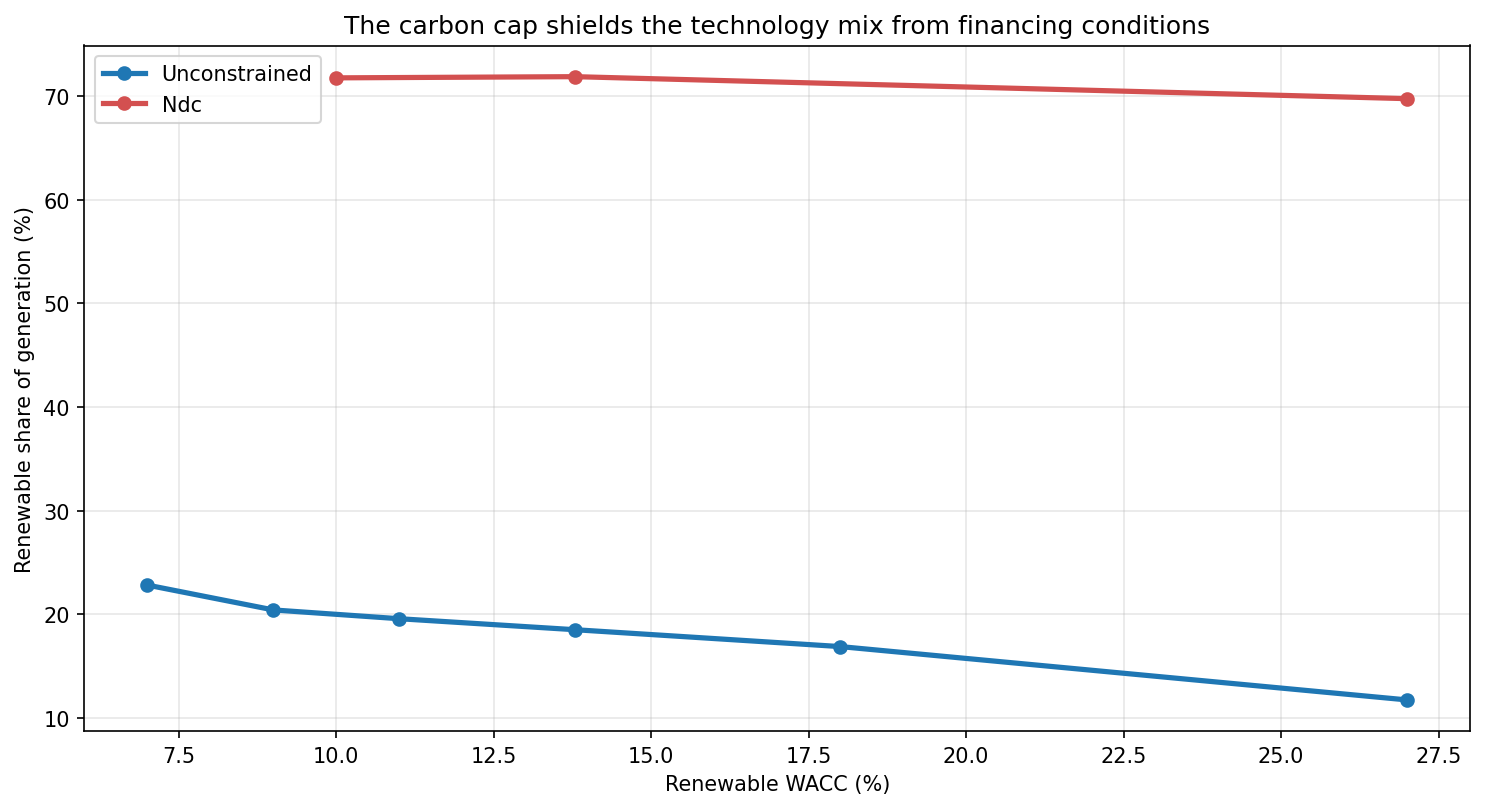

In [115]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for c, col in [("unconstrained","#1f77b4"), ("ndc","#d35050")]:
    sub = sweep[sweep.constraint == c].sort_values("wacc")
    ax.plot(sub.wacc * 100, sub.share_renew_pct, "o-", color=col, lw=2.5, label=c.capitalize())
ax.set_xlabel("Renewable WACC (%)")
ax.set_ylabel("Renewable share of generation (%)")
ax.set_title("The carbon cap shields the technology mix from financing conditions")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "fig2_carbon_shield.png", bbox_inches="tight")
plt.show()

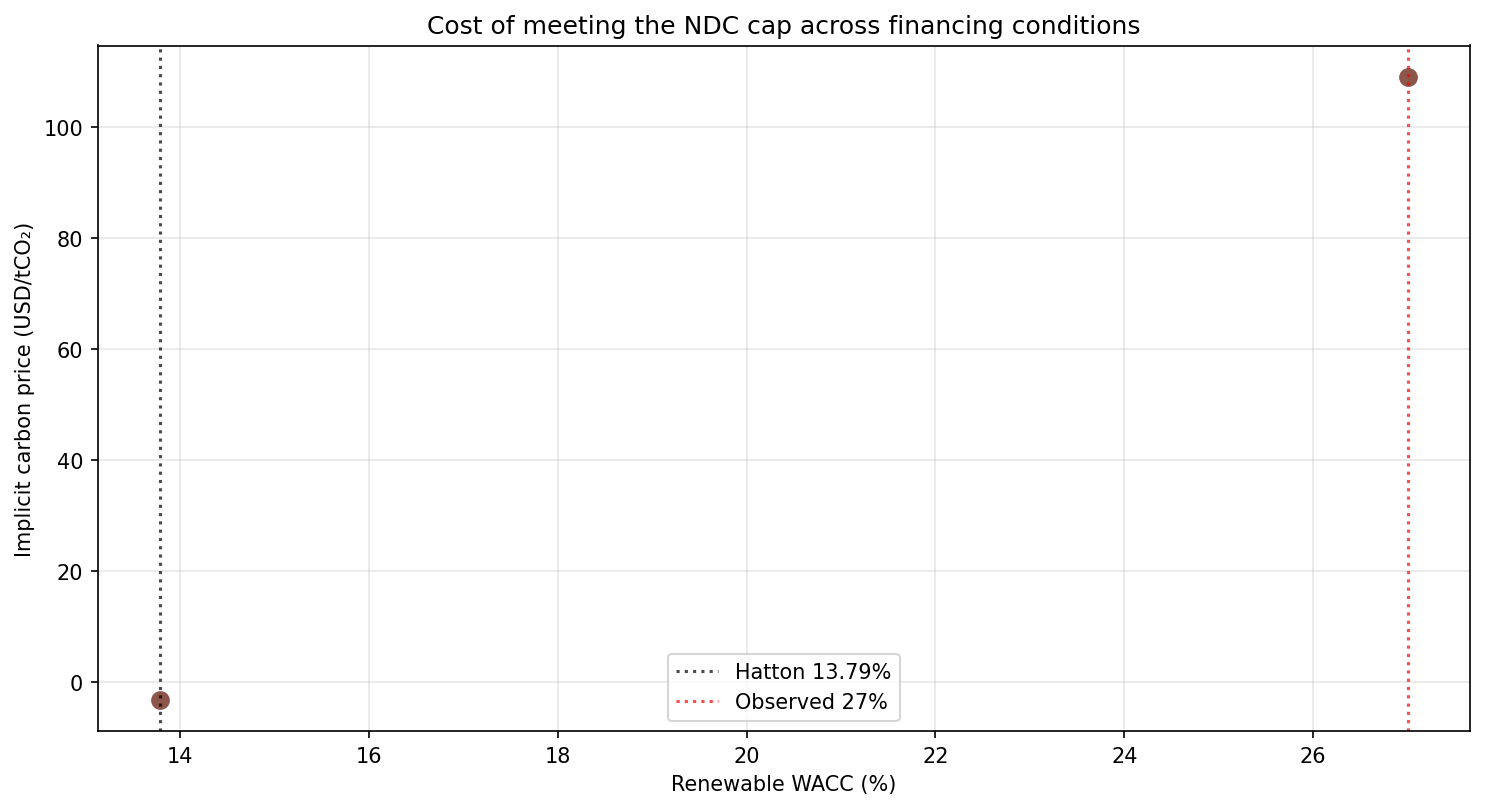

,wacc,emissions_mt_co2_ndc,emissions_mt_co2_unconstrained,share_renew_pct_ndc,share_renew_pct_unconstrained,total_cost_bn_usd_ndc,total_cost_bn_usd_unconstrained,cost_premium_bn,emissions_reduction,implicit_carbon_usd_per_tco2,wacc_pct
0,0.07,NaN,25.55,NaN,22.81,NaN,2.56,NaN,NaN,NaN,7.00
1,0.09,NaN,26.37,NaN,20.41,NaN,2.65,NaN,NaN,NaN,9.00
2,0.10,8.82,NaN,71.74,NaN,2.04,NaN,NaN,NaN,NaN,10.00
3,0.11,NaN,26.66,NaN,19.57,NaN,2.70,NaN,NaN,NaN,11.00
4,0.14,8.82,27.03,71.86,18.51,2.69,2.75,-0.06,18.21,-3.22,13.79
5,0.18,NaN,27.60,NaN,16.88,NaN,2.81,NaN,NaN,NaN,18.00
6,0.27,8.82,29.39,69.73,11.73,5.09,2.85,2.24,20.56,109.00,27.00


In [116]:
# Merge constrained and unconstrained at matching WACC
pivot = sweep.pivot_table(index="wacc", columns="constraint",
                          values=["total_cost_bn_usd","emissions_mt_co2","share_renew_pct"])
pivot.columns = ["_".join(c) for c in pivot.columns]
pivot = pivot.reset_index()

pivot["cost_premium_bn"] = pivot["total_cost_bn_usd_ndc"] - pivot["total_cost_bn_usd_unconstrained"]
pivot["emissions_reduction"] = pivot["emissions_mt_co2_unconstrained"] - pivot["emissions_mt_co2_ndc"]
pivot["implicit_carbon_usd_per_tco2"] = (
    pivot["cost_premium_bn"] * 1e9 / (pivot["emissions_reduction"] * 1e6)
).replace([np.inf,-np.inf], np.nan)
pivot["wacc_pct"] = (pivot.wacc * 100).round(2)
pivot.to_csv(OUT / "table3_decarbonisation.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(pivot.wacc_pct, pivot.implicit_carbon_usd_per_tco2, "o-", color="#8c564b", lw=2.5, ms=8)
ax.set_xlabel("Renewable WACC (%)")
ax.set_ylabel("Implicit carbon price (USD/tCO₂)")
ax.set_title("Cost of meeting the NDC cap across financing conditions")
ax.axvline(13.79, color="black", ls=":", alpha=0.7, label="Hatton 13.79%")
ax.axvline(27, color="red", ls=":", alpha=0.7, label="Observed 27%")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "fig3_implicit_carbon_price.png", bbox_inches="tight")
plt.show()
pivot.round(2)

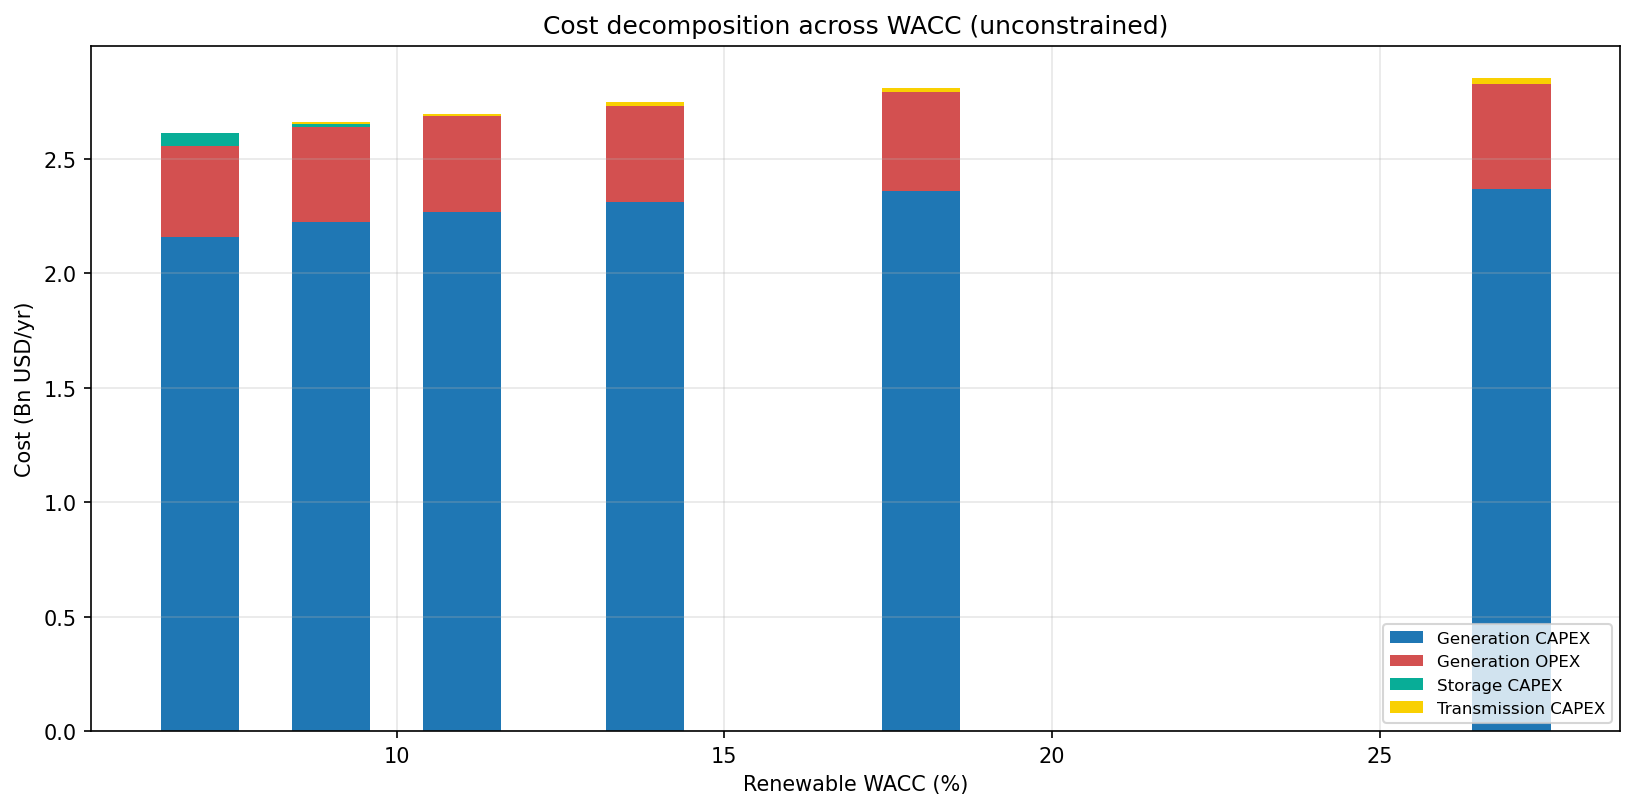

In [117]:
cost_cols = ["gen_capex_bn_usd","gen_opex_bn_usd","storage_capex_bn_usd","line_capex_bn_usd"]
cost_labels = ["Generation CAPEX","Generation OPEX","Storage CAPEX","Transmission CAPEX"]
colors = ["#1f77b4","#d35050","#08ad97","#f9d002"]

fig, ax = plt.subplots(figsize=(11, 5.5))
sub = sweep[sweep.constraint=="unconstrained"].sort_values("wacc")
x = sub.wacc * 100
bottom = np.zeros(len(sub))
for col, lab, col_ in zip(cost_cols, cost_labels, colors):
    ax.bar(x, sub[col].values, bottom=bottom, label=lab, color=col_, width=1.2)
    bottom += sub[col].values
ax.set_xlabel("Renewable WACC (%)")
ax.set_ylabel("Cost (Bn USD/yr)")
ax.set_title("Cost decomposition across WACC (unconstrained)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / "fig4_cost_decomposition.png", bbox_inches="tight")
plt.show()

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


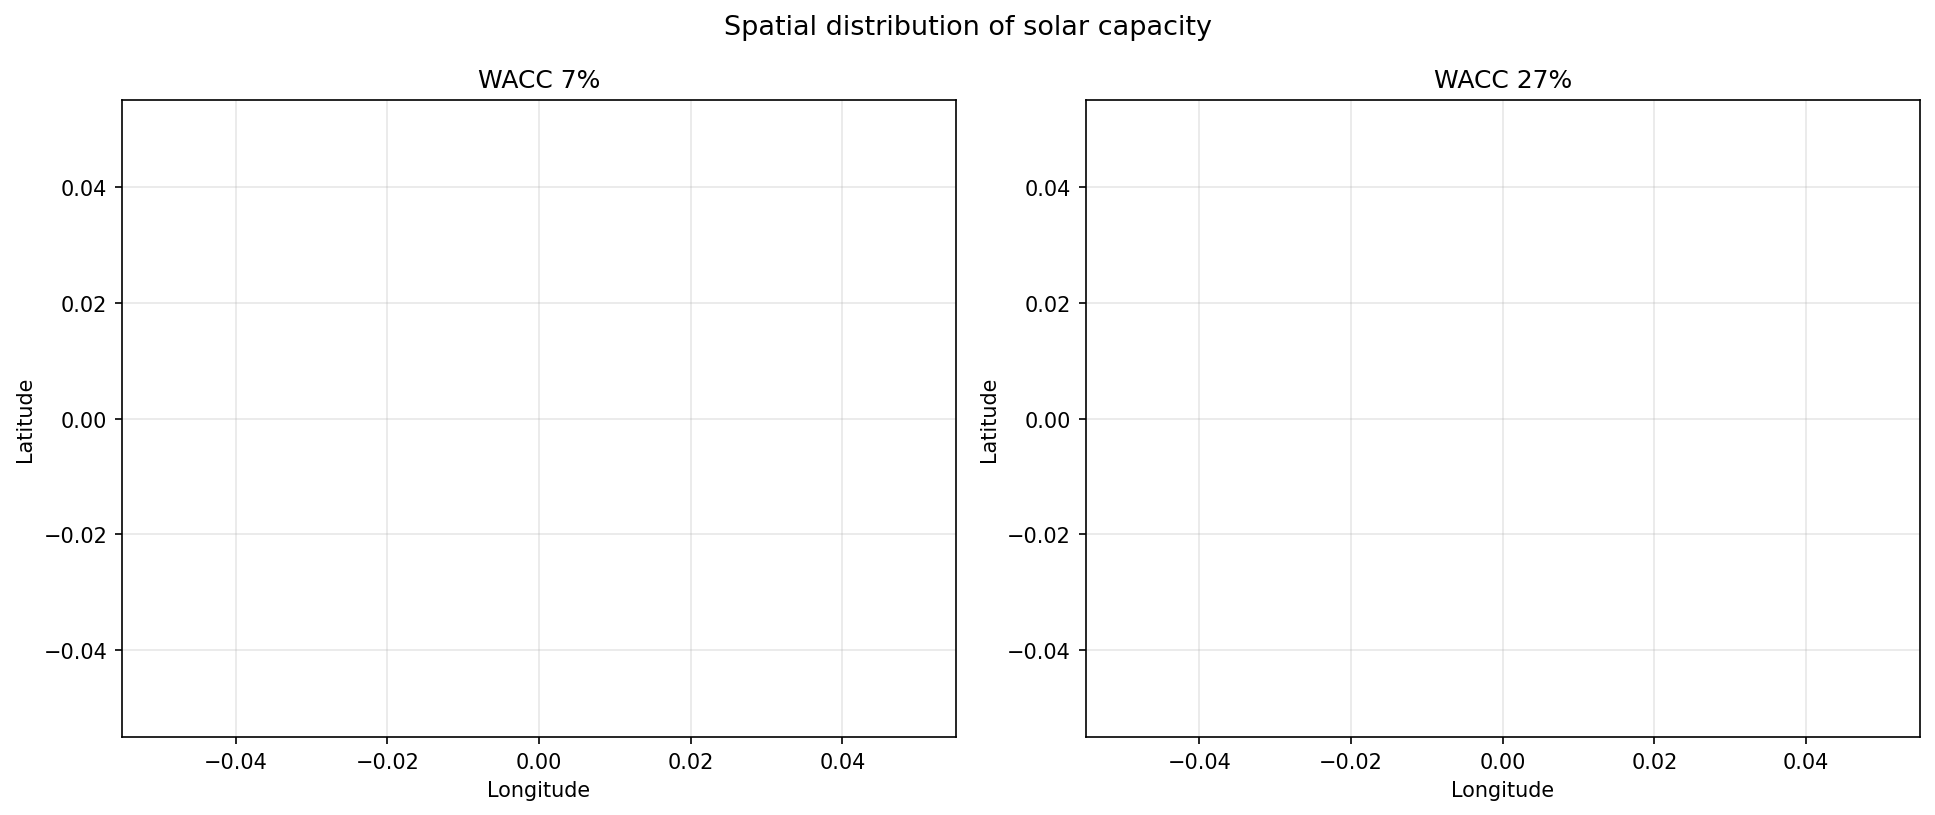

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, wacc in zip(axes, [0.07, 0.27]):
    tag = f"{int(round(wacc*10000)):04d}"
    n = load_network(f"nigeria_2030_wacc_{tag}")
    if n is None: continue
    solar = n.generators[n.generators.carrier == "solar"].copy()
    solar["x"] = n.buses.loc[solar.bus, "x"]
    solar["y"] = n.buses.loc[solar.bus, "y"]
    sc = ax.scatter(solar.x, solar.y, s=solar.p_nom_opt/50,
                    c=solar.p_nom_opt, cmap="YlOrRd", alpha=0.7, edgecolors="black")
    ax.set_title(f"WACC {wacc*100:.0f}%")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
fig.suptitle("Spatial distribution of solar capacity", fontsize=13)
plt.tight_layout()
plt.savefig(OUT / "fig5_solar_spatial.png", bbox_inches="tight")
plt.show()

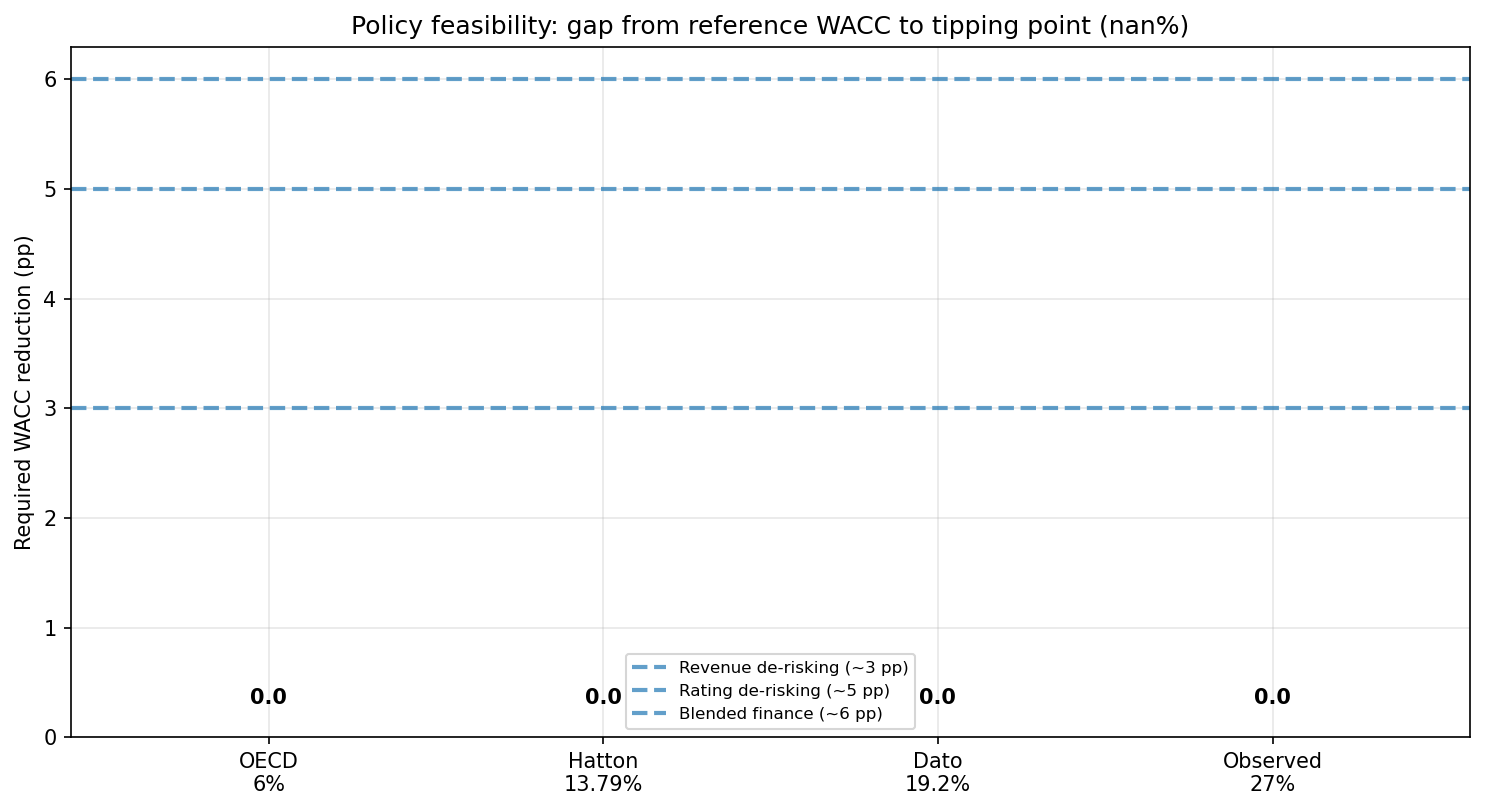

In [119]:
instrument_classes = {
    "Revenue de-risking": 3,
    "Rating de-risking":  5,
    "Blended finance":    6,
}
refs = {"OECD\n6%":6, "Hatton\n13.79%":13.79, "Dato\n19.2%":19.2, "Observed\n27%":27}

tipping = inf.loc[inf.constraint=="unconstrained","solar_cap > gas_cap"].iloc[0]

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(refs))
gaps = [max(0, w - tipping) for w in refs.values()]
colors = ["#2ca02c","#1f77b4","#ff7f0e","#d62728"]
bars = ax.bar(x, gaps, color=colors, alpha=0.75)
for i, (label, eff) in enumerate(instrument_classes.items()):
    ax.axhline(eff, ls="--", lw=2, alpha=0.7, label=f"{label} (~{eff} pp)")
ax.set_xticks(x)
ax.set_xticklabels(list(refs.keys()))
ax.set_ylabel("Required WACC reduction (pp)")
ax.set_title(f"Policy feasibility: gap from reference WACC to tipping point ({tipping:.1f}%)")
ax.legend(fontsize=8)
for bar, g in zip(bars, gaps):
    ax.text(bar.get_x()+bar.get_width()/2, g+0.3, f"{g:.1f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "fig6_policy_feasibility.png", bbox_inches="tight")
plt.show()

In [120]:
gas = df[df.constraint.isin(list(GAS_RUNS.keys()))][[
    "constraint","cap_solar_gw","cap_CCGT_gw","cap_OCGT_gw",
    "share_renew_pct","share_gas_pct","emissions_mt_co2","cost_per_mwh_usd"
]].copy()
# Add the reference point at $3.39 from the main sweep
ref = sweep[(sweep.constraint=="unconstrained") & (sweep.wacc.round(4)==0.1379)][[
    "constraint","cap_solar_gw","cap_CCGT_gw","cap_OCGT_gw",
    "share_renew_pct","share_gas_pct","emissions_mt_co2","cost_per_mwh_usd"
]]
gas_all = pd.concat([ref, gas], ignore_index=True)
gas_all.to_csv(OUT / "table4_gas_price.csv", index=False)
gas_all.round(2)

,constraint,cap_solar_gw,cap_CCGT_gw,cap_OCGT_gw,share_renew_pct,share_gas_pct,emissions_mt_co2,cost_per_mwh_usd
0,unconstrained,2.81,3.44,28.56,18.51,81.49,27.03,38.14
1,gas_600,2.97,3.44,28.43,18.91,81.09,26.89,39.59


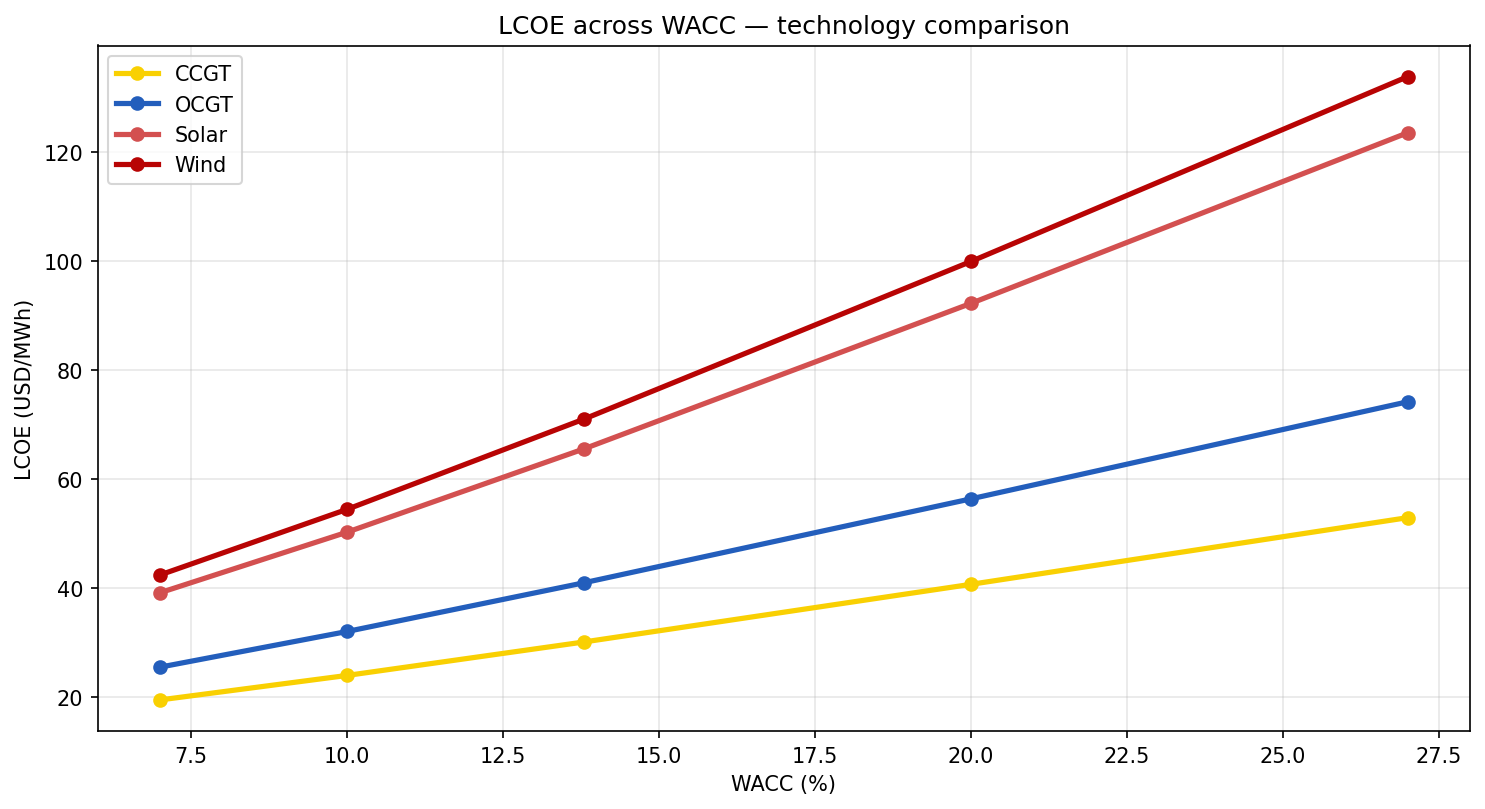

In [121]:
# Compute LCOEs from annualised capital and O&M costs
def lcoe(capex_usd_kw, fom_pct, vom_usd_mwh, fuel_usd_mwh, eff, cf, wacc, lifetime):
    crf = wacc * (1+wacc)**lifetime / ((1+wacc)**lifetime - 1)
    annual_capex = capex_usd_kw * crf * 1000  # USD/MW/yr
    return annual_capex / (cf * 8760) + vom_usd_mwh + fuel_usd_mwh / eff

# Approximate technology parameters (adapt to your costs.csv)
tech = {
    "Solar":  {"capex": 800,  "cf": 0.20, "eff": 1.0,  "vom": 0,  "fuel": 0,   "fom": 0.01, "life": 25},
    "Wind":   {"capex": 1300, "cf": 0.30, "eff": 1.0,  "vom": 0,  "fuel": 0,   "fom": 0.015,"life": 25},
    "CCGT":   {"capex": 850,  "cf": 0.55, "eff": 0.58, "vom": 4,  "fuel": 0.748, "fom": 0.025,"life": 30},
    "OCGT":   {"capex": 450,  "cf": 0.20, "eff": 0.41, "vom": 3,  "fuel": 0.748, "fom": 0.035,"life": 30},
}

waccs = [0.07, 0.10, 0.1379, 0.20, 0.27]
lcoe_rows = []
for name, p in tech.items():
    for w in waccs:
        lcoe_rows.append({
            "tech": name, "wacc": w*100,
            "LCOE_usd_mwh": lcoe(p["capex"], p["fom"], p["vom"], p["fuel"], p["eff"], p["cf"], w, p["life"])
        })

lcoe_df = pd.DataFrame(lcoe_rows).pivot(index="wacc", columns="tech", values="LCOE_usd_mwh")
lcoe_df.to_csv(OUT / "table5_lcoe.csv")
lcoe_df.round(2)

fig, ax = plt.subplots(figsize=(10, 5.5))
for col, color in zip(lcoe_df.columns, ["#f9d002","#235ebc","#d35050","#b80404"]):
    ax.plot(lcoe_df.index, lcoe_df[col], "o-", label=col, color=color, lw=2.5)
ax.set_xlabel("WACC (%)")
ax.set_ylabel("LCOE (USD/MWh)")
ax.set_title("LCOE across WACC — technology comparison")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "fig7_lcoe_curves.png", bbox_inches="tight")
plt.show()

In [122]:
baselines = df[df.constraint.isin(list(BASELINES.keys()))][[
    "constraint","cap_solar_gw","cap_CCGT_gw","cap_OCGT_gw","cap_battery_gw",
    "share_renew_pct","share_gas_pct","emissions_mt_co2","cost_per_mwh_usd"
]].copy()
baselines.to_csv(OUT / "table6_baselines.csv", index=False)
baselines.round(2)

,constraint,cap_solar_gw,cap_CCGT_gw,cap_OCGT_gw,cap_battery_gw,share_renew_pct,share_gas_pct,emissions_mt_co2,cost_per_mwh_usd
9,B1_uniform_10,0.0,3.44,8.74,0.0,11.73,88.27,26.42,6.27
10,B2_split_hatton,2.3,3.44,28.99,0.0,17.28,82.72,33.34,37.32


In [ ]:
with pd.ExcelWriter(OUT / "nigeria_2030_full_analysis.xlsx") as xl:
    df.to_excel(xl, "master", index=False)
    t1.to_excel(xl, "table1_headline", index=False)
    inf.to_excel(xl, "table2_inflection", index=False)
    pivot.to_excel(xl, "table3_decarbonisation", index=False)
    gas_all.to_excel(xl, "table4_gas_price", index=False)
    lcoe_df.to_excel(xl, "table5_lcoe")
    baselines.to_excel(xl, "table6_baselines", index=False)
print("Workbook saved:", OUT / "nigeria_2030_full_analysis.xlsx")

In [66]:
import pypsa
n = pypsa.Network("/Users/fowfloi/Documents/pypsa-earth/results/nigeria_2030_wacc_1379/networks/elec_s_10_ec_lcopt_1h.nc")
solar = n.generators[n.generators.carrier == "solar"]
print("Solar generators:")
print(solar[["p_nom","p_nom_opt","p_nom_extendable","capital_cost","marginal_cost"]].head(3).to_string())
print("\nGas CCGT generators:")
gas = n.generators[n.generators.carrier == "CCGT"]
print(gas[["p_nom","p_nom_opt","p_nom_extendable","capital_cost","marginal_cost"]].head(3).to_string())

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_1h.nc has buses, carriers, generators, global_constraints, lines, line_types, loads, storage_units


Solar generators:
                 p_nom  p_nom_opt  p_nom_extendable  capital_cost  marginal_cost
Generator                                                                       
NG0 0 solar  12.817717   0.002901              True  42079.853517       0.009412
NG0 1 solar  28.593370   0.013955              True  42079.853517       0.009139
NG0 2 solar  37.467174   0.005714              True  42079.853517       0.009102

Gas CCGT generators:
             p_nom    p_nom_opt  p_nom_extendable   capital_cost  marginal_cost
Generator                                                                      
NG0 0 CCGT   624.0   624.000004              True  162697.337654       4.499920
NG0 2 CCGT  1320.0  1320.001285              True  162697.337654       4.500517
NG0 4 CCGT   480.0   480.000120              True  162697.337654       4.499178
